<a href="https://colab.research.google.com/github/mikakia/FL_VIP/blob/main/knee_images.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [21]:
import os
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import chisquare, f_oneway, ks_2samp
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms



# Load data

In [2]:
folder_dir = '/Users/tsampikakiaourtzi/Documents/FL_VIP/knee_osteo/data/raw/knee_images'

In [3]:
print("Exists:", os.path.exists(folder_dir))
print("folder_dir =", folder_dir)

Exists: True
folder_dir = /Users/tsampikakiaourtzi/Documents/FL_VIP/knee_osteo/data/raw/knee_images


In [4]:
knee_images = datasets.ImageFolder(root=folder_dir, transform=transforms.ToTensor())
print(type(knee_images[0]))

<class 'tuple'>


# Explore Data

In [5]:
print(f"Classes:{knee_images.classes}")
print(f"Class and Index: {knee_images.class_to_idx}")
print(f"Total images: {len(knee_images)}")

Classes:['0', '1', '2', '3', '4']
Class and Index: {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4}
Total images: 7009


In [6]:
counts = Counter(knee_images.targets)
for class_idx, count in sorted(counts.items()):
    print(f"Class {knee_images.classes[class_idx]}: {count} images")

Class 0: 2920 images
Class 1: 1342 images
Class 2: 1516 images
Class 3: 980 images
Class 4: 251 images


In [7]:
image, label = knee_images[0]
print(image.shape)
print(label)

torch.Size([3, 224, 224])
0


## Plot of count of images per class

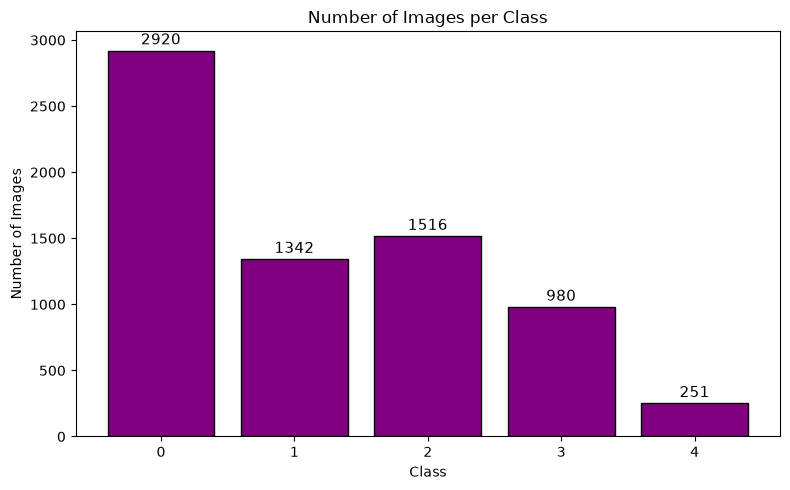

In [8]:
class_names = knee_images.classes
values = [counts[i] for i in range(len(class_names))]


plt.figure(figsize=(8, 5))
bars = plt.bar(class_names, values, color='purple', edgecolor='black')

for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
             str(val), ha='center', va='bottom', fontsize=11)

plt.title('Number of Images per Class')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.tight_layout()
plt.show()

## Plot of an example image from each class

count 1
index 0
count 2
index 2920
count 3
index 4262
count 4
index 5778
count 5
index 6758


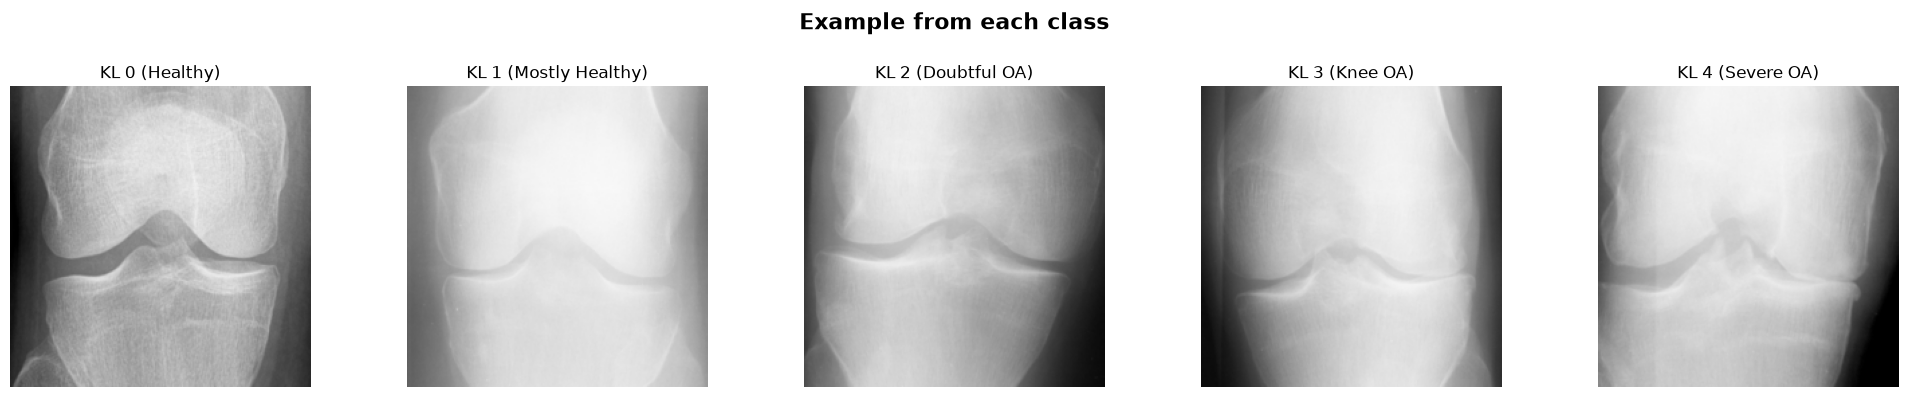

In [9]:


class_labels = {
    0: 'KL 0 (Healthy)',
    1: 'KL 1 (Mostly Healthy)',
    2: 'KL 2 (Doubtful OA)',
    3: 'KL 3 (Knee OA)',
    4: 'KL 4 (Severe OA)'
}

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

count = 0
for class_idx in range(len(knee_images.classes)):
    count = count + 1
    print("count", count)

    idx = knee_images.targets.index(class_idx)
    print("index", idx)

    img, label = knee_images[idx]

    axes[class_idx].imshow(img.permute(1, 2, 0))
    axes[class_idx].set_title(f'{class_labels[class_idx]}')
    axes[class_idx].axis('off')

plt.suptitle('Example from each class\n', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Class Distribution

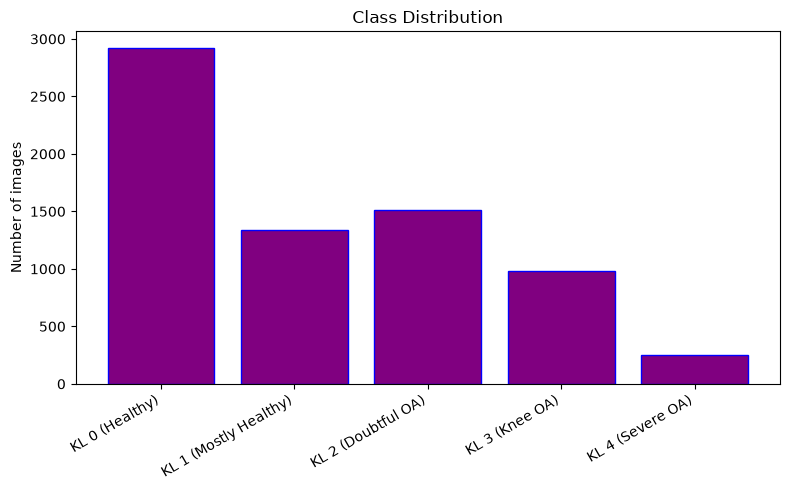

KL 0 (Healthy): 2920 images (41.7%)
KL 1 (Mostly Healthy): 1342 images (19.1%)
KL 2 (Doubtful OA): 1516 images (21.6%)
KL 3 (Knee OA): 980 images (14.0%)
KL 4 (Severe OA): 251 images (3.6%)


In [10]:
label_counts = Counter(knee_images.targets)
labels_sorted = sorted(label_counts.items())

plt.figure(figsize=(8, 5))
plt.bar([class_labels[k] for k, v in labels_sorted], [v for k, v in labels_sorted],color='purple',edgecolor='blue')
plt.xticks(rotation=30, ha='right')
plt.ylabel('Number of images')
plt.title('Class Distribution')
plt.tight_layout()
plt.show()

for k, v in labels_sorted:
    print(f"{class_labels[k]}: {v} images ({v/len(knee_images.targets)*100:.1f}%)")

# Pie chart of class distribution

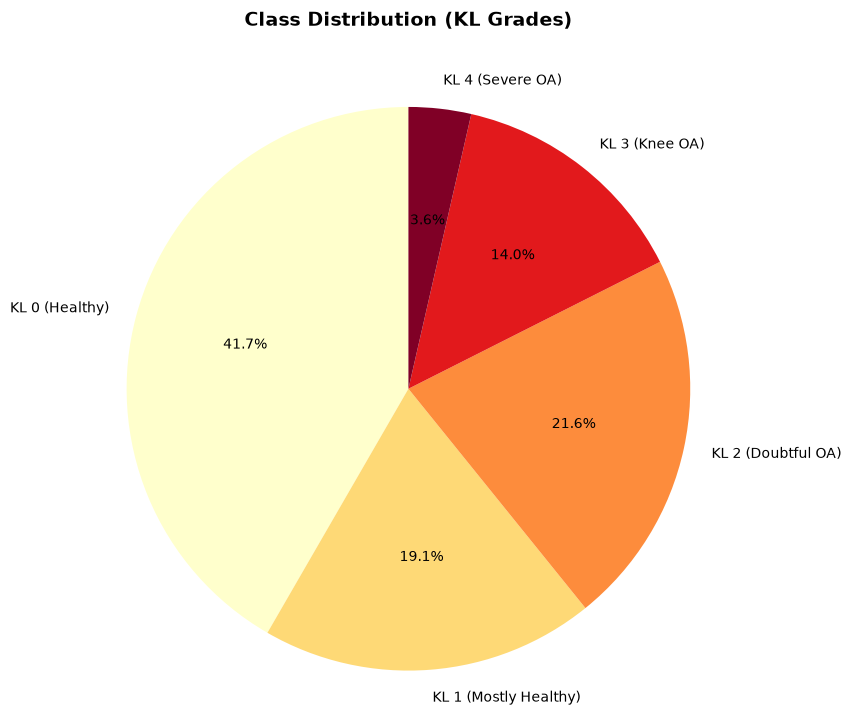

In [11]:
sizes = [v for k, v in labels_sorted]
labels = [class_labels[k] for k, v in labels_sorted]
colors = plt.cm.YlOrRd([i / (len(sizes)-1) for i in range(len(sizes))])

plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
plt.title('Class Distribution (KL Grades)\n\n', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.show()

# Chi-squared test
For class imbalance
This test compares the actual number of images in each KL grade class (observed values) against the number we would expect if all five classes were equally represented (expected values under a uniform distribution).

Result: The chi-square test gave a statistic of 2729.56 and a p-value of less than 0.0001, showing that the number of images in each class is very different from what we'd expect if the classes were equal in size. Because this p-value is so small, we can say with confidence that this imbalance is real and not just by chance. 

Statistic: how far your actual class counts are from what you'd expect if all 5 classes had equal numbers of images. 
χ² = Σ [ (observed - expected)² / expected ]


In [12]:
observed = [v for k, v in labels_sorted]
expected = [sum(observed)/len(observed)] * len(observed)

stat, p = chisquare(observed, expected)
print(f"Chi-square: {stat:.2f}, p-value: {p:.4e}")

Chi-square: 2727.78, p-value: 0.0000e+00


# ANOVA across all the classes and pairwise between the classes (for mean brightness)
Mean pixel intensit, not on overall image brightness. Two X-rays can have identical average pixel intensity while looking completely different in terms of joint structure.

Comparison	KS stat	p-value	Significant?
KL0 vs KL1	0.180	0.3959	No
KL1 vs KL2	0.140	0.7166	No
KL2 vs KL3	0.160	0.5487	No
KL3 vs KL4	0.180	0.3959	No

KS test (Kolmogorov–Smirnov test)
Do these two specific classes have differently-shaped distributions?

Compares the entire distribution shape (not just the mean) of two groups at a time.
The KS statistic is the maximum distance between the two groups' cumulative distribution functions (CDFs). Meaning how far apart their distributions are at their most different point.


In [ ]:


def get_mean_intensities(class_idx, n_samples=50):
    indices = [i for i, t in enumerate(knee_images.targets) if t == class_idx][:n_samples]
    return [knee_images[i][0].numpy().mean() for i in indices]

class_intensities = {c: get_mean_intensities(c) for c in range(5)} # mean brightness

# ANOVA across all classes
stat, p = f_oneway(*class_intensities.values())
print(f"ANOVA: F={stat:.2f}, p={p:.4e}")

# pairwise KS test between classes
for a, b in [(0,1), (1,2), (2,3), (3,4)]:
    stat, p = ks_2samp(class_intensities[a], class_intensities[b])
    print(f"KL{a} vs KL{b}: KS stat={stat:.3f}, p={p:.4f}")

ANOVA: F=1.37, p=2.4358e-01
KL0 vs KL1: KS stat=0.180, p=0.3959
KL1 vs KL2: KS stat=0.140, p=0.7166
KL2 vs KL3: KS stat=0.160, p=0.5487
KL3 vs KL4: KS stat=0.180, p=0.3959



# ANOVA on Contrast (Pixel Standard Deviation)

The F-statistic, F = 1.04, and the p-value, p = 0.39, was much higher than 0.05, meaning the contrast levels between the different KL grades are not meaningfully different, and any  differences observed are likely just due to random variation and not a real pattern.
No significant difference in contrast between the classes either. 


In [14]:
def get_std_intensities(class_idx, n_samples=30):
    indices = [i for i, t in enumerate(knee_images.targets) if t == class_idx][:n_samples]
    return [knee_images[i][0].numpy().std() for i in indices]

class_stds = {c: get_std_intensities(c) for c in range(5)} # contrast values from each class
stat, p = f_oneway(*class_stds.values())
print(f"ANOVA on contrast: F={stat:.2f}, p={p:.4e}")

ANOVA on contrast: F=1.04, p=3.8656e-01


Overall: The differences between KL grades are not about overall lighting/contrast, but about specific structural details located in particular regions of the image..

# PCA on pixels

In [ ]:
def compare_classes_pca(dataset, class_a, class_b, colors, class_labels=None,
                          batch_size=32, num_workers=0):

    if class_labels is None:
        class_labels = {class_a: str(class_a), class_b: str(class_b)}

    # keep two classes at a time
    targets = np.array(dataset.targets)
    indices = np.where((targets == class_a) | (targets == class_b))[0]
    subset = Subset(dataset, indices)
    print(f"Class {class_a} vs {class_b} subset size: {len(subset)}")

    loader = DataLoader(subset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

    # extract raw pixel features
    X_list, y_list = [], []
    for imgs, targets_batch in loader:
        flat = imgs.view(imgs.size(0), -1).numpy()
        X_list.append(flat)
        y_list.append(targets_batch.numpy())

    X = np.concatenate(X_list, axis=0)
    y = np.concatenate(y_list, axis=0)

    # standardize features and apply PCA
    X_scaled = StandardScaler().fit_transform(X)
    pca = PCA(n_components=2, random_state=42)
    emb = pca.fit_transform(X_scaled)

    # silhouette score
    sil = silhouette_score(X_scaled, y)
    print(f"Silhouette score class {class_a} vs {class_b}: {sil:.4f}")

    # plotting
    plt.figure(figsize=(8, 6))
    for class_idx in [class_a, class_b]:
        mask = y == class_idx
        plt.scatter(emb[mask, 0], emb[mask, 1], c=colors[class_idx],
                    label=class_labels[class_idx], alpha=0.6, s=20)

    plt.title(f'PCA on raw pixels \nSilhouette: {sil:.4f}')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.legend()
    plt.tight_layout()
    plt.show()

   

In [30]:
class_labels = {
    0: 'KL 0 (Healthy)',
    1: 'KL 1 (Mostly Healthy)',
    2: 'KL 2 (Doubtful OA)',
    3: 'KL 3 (Definite OA)',
    4: 'KL 4 (Severe OA)'
}

Class 1 vs 2 subset size: 2858
Silhouette score class 1 vs 2: 0.0010


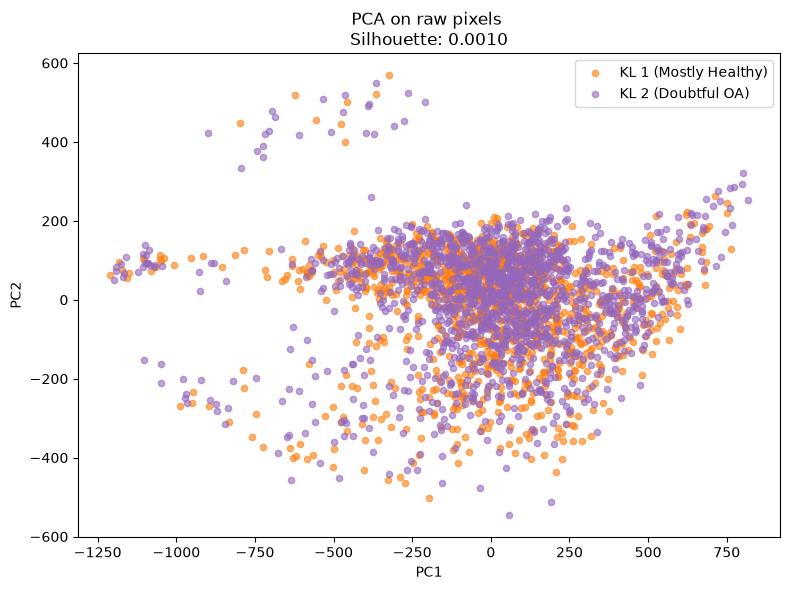

In [43]:
# class 1 vs 2
compare_classes_pca(knee_images, 1, 2,colors={1: 'tab:orange', 2: 'tab:purple'},class_labels=class_labels)

Class 2 vs 3 subset size: 2496
Silhouette score class 2 vs 3: -0.0004


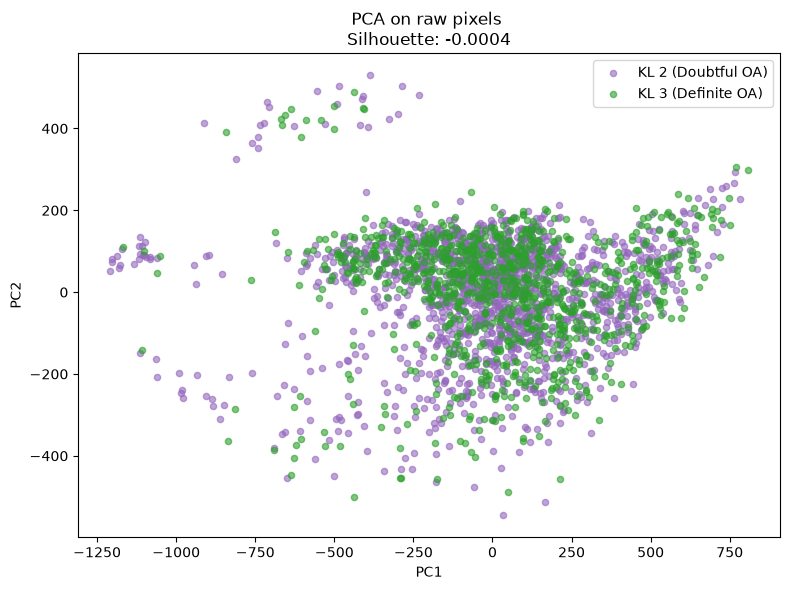

In [44]:
# class 2 vs 3
compare_classes_pca(knee_images, 2, 3,
                     colors={2: 'tab:purple', 3: 'tab:green'},
                     class_labels=class_labels)


Class 3 vs 4 subset size: 1231
Silhouette score class 3 vs 4: 0.0277


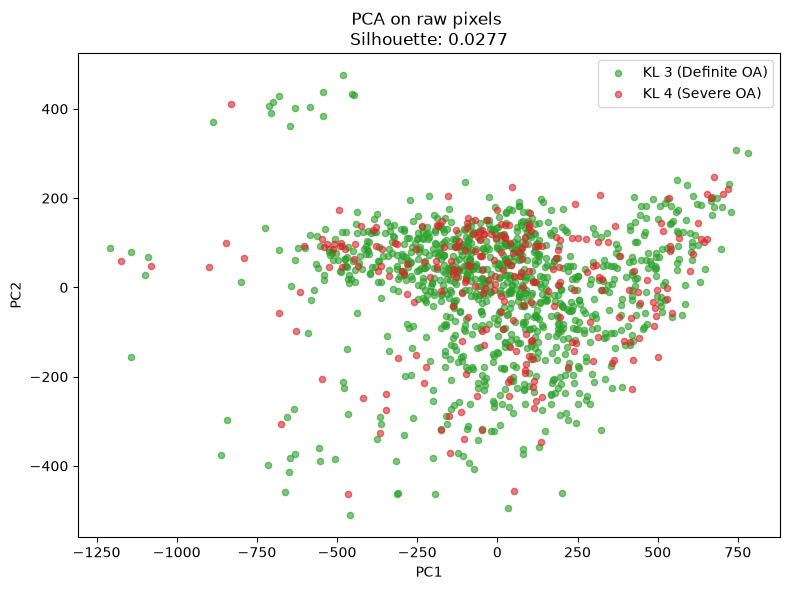

In [45]:
# class 3 vs 4
compare_classes_pca(knee_images, 3, 4,
                     colors={3: 'tab:green', 4: 'tab:red'},
                     class_labels=class_labels)


Class 1 vs 4 subset size: 1593
Silhouette score class 1 vs 4: 0.0572


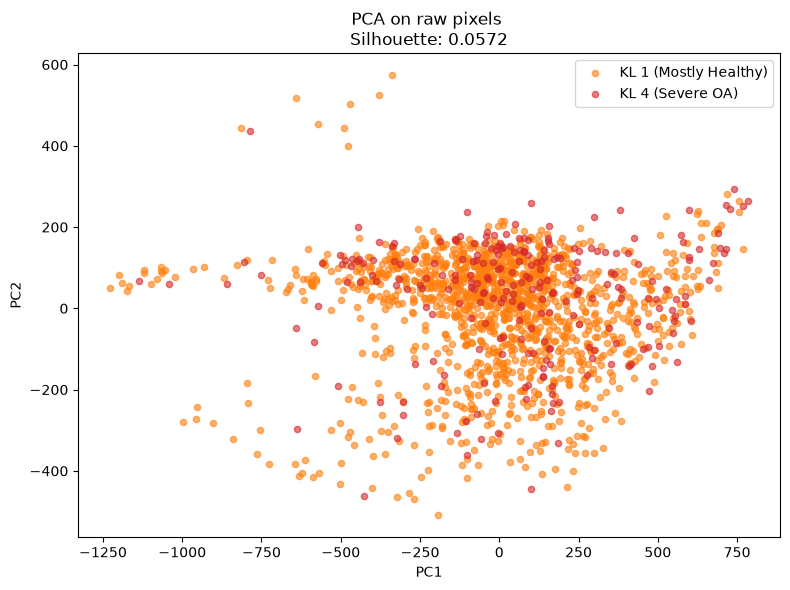

In [46]:
# class 1 vs 4
compare_classes_pca(knee_images, 1, 4,
                     colors={1: 'tab:orange', 4: 'tab:red'},
                     class_labels=class_labels)
